<a href="https://colab.research.google.com/github/evalopvl/Paseo_aleatorio_simple/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Paseo Aleatorio Simple**

El Paseo Aleatorio Simple es un proceso estocástico definido en $T = \{1, 2, ...\} = \mathbb{N}$, que toma valores en  $S = \mathbb{Z}$.

Para cada $t \in \mathbb{N}$, el proceso se define como $$X_t = \sum_{s=1}^{t} Z_s$$ siendo $\{Z_s\}_{s \in \mathbb{N}}$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) según la siguiente distribución: $$P(Z_s = 1) = p, \quad P(Z_s = -1) = 1-p$$

El objetivo de este notebook es implementar una simulación de este proceso y analizar cómo el parámetro
$p$ influye en el comportamiento de las trayectorias.

In [ ]:
# Importamos las librerías que vamos a necesitar
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# Inicializamos la semilla de números aleatorios
# Esto permite que los resultados sean determinísticos y se puedan reproducir
# Si queremos ver como cambian las trayectorias en cada ejecución,
# se puede comentar
np.random.seed(127)

## Función para simular el PAS

Se define una función `simular_PAS` que reciba tres argumentos:
* p: la probabilidad de tomar el valor 1 en cada paso. Un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

In [ ]:
def simular_PAS(p,n,reps=1):
    """
     Input:
      p: la probabilidad de tomar el valor 1 en cada paso. Un valor entre 0 y 1.
      n: el número de pasos a simular para cada trayectoria. Un número natural.
      reps: el número de trayectorias a simular. Un número natural

     Output:
      Un array con dimensionalidad (reps, n), que contenga los valores del PAS
      en cada paso para cada trayectoria.
    """

    # Creamos una matriz con reps filas y n columnas, es decir, un array con
    # shape (reps, n)
    # lo inicializamos a 1 y -1 usando la función numpy.random.choice
    result = np.random.choice([1, -1], size = (reps, n), p = [p, 1-p])

    # Sumamos las apariciones por filas, para ello usamos la función
    # numpy.cumsum
    result = np.cumsum(result, axis = 1)

    # Devolvemos el resultado
    return result

### Funciones utilizadas:
La función `numpy.random.choice` permite crear un array con forma `size`, eligiendo aleatoriamente entre los elementos de un conjunto (primer argumento) según las probabilidades especificadas en el parámetro `p`.

La función `numpy.cumsum` calcula las sumas acumuladas de los elementos de un array pasado como argumento.  
La opción `axis = 1`, indica que debe sumar por filas.

##Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Las funciones que se van a utilizar para visualizar las distintas trayectorias que hemos simulado son las siguientes:

La función `numpy.transpose` permite transponer una matriz o vector.

La función `matplotlib.pyplot.plot` permite representar gráficamente una secuencia de datos mediante una línea. Cuando se le pasa un único array, interpreta sus valores como las coordenadas en el eje vertical, mientras que el eje horizontal corresponde a los índices de dichos valores.

Sin embargo, la función que simula el Paseo Aleatorio Simple devuelve un array con forma (reps, n), donde cada fila representa una trayectoria y cada columna un instante temporal.

Por otro lado, la función `matplotlib.pyplot.plot` interpreta, cuando recibe un array bidimensional, que cada columna corresponde a una serie de datos a representar.

En una primera instancia, se podría recurrir a un `bucle for` para graficar cada trayectoria de forma individual. Sin embargo, este enfoque no es eficiente desde el punto de vista computacional.

Para evitarlo, se utiliza la función `numpy.transpose`. Al transponer el array a forma (n, reps), cada trayectoria pasa a estar contenida en una columna, lo que permite a `matplotlib.pyplot.plot` representarlas todas simultáneamente de forma eficiente.

In [ ]:
# Declaramos las variables que se van a repetir durante esta sección
n = 500
reps = 5

### Paseo aleatorio simple con p = 0.5

In [ ]:
p = 0.5

In [ ]:
# Llamamos a la función con los parámetros adecuados, en este caso
# una probabilidad del 0.5, 500 pasos y 5 repeticiones.
# Se obtiene un array de 5 x 500
x_t = simular_PAS(p, n, reps)

# Se transpone el array
x_t = np.transpose(x_t)

Text(0, 0.5, '$X_t$')

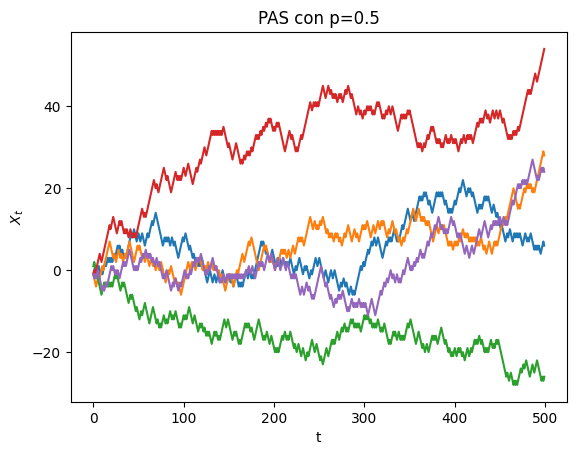

In [ ]:
# Dibujamos la gráfica
plt.plot(x_t)

# Damos título a la gráfica y a los ejes
plt.title("PAS con p=0.5")
plt.xlabel("t")
plt.ylabel("$X_t$")

### Paseo aleatorio simple con p = 0.6

In [ ]:
p = 0.6

In [ ]:
# Llamamos a la función con p = 0.6
x_t = simular_PAS(p, n, reps)

# Se transpone la matriz
x_t = np.transpose(x_t)

Text(0, 0.5, '$X_t$')

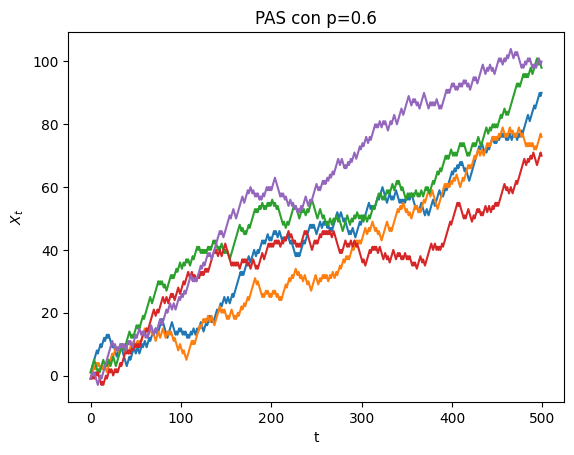

In [ ]:
plt.plot(x_t)

# Damos un título a la gráfica y a los ejes
plt.title("PAS con p=0.6")
plt.xlabel("t")
plt.ylabel("$X_t$")

### Paseo aleatorio simple con p = 0.4

In [ ]:
p = 0.4

In [ ]:
# Llamamos a la función simular_PAS con p = 0.4
x_t = simular_PAS(p, n, reps)

# Se transpone la matriz
x_t = np.transpose(x_t)

Text(0, 0.5, '$X_t$')

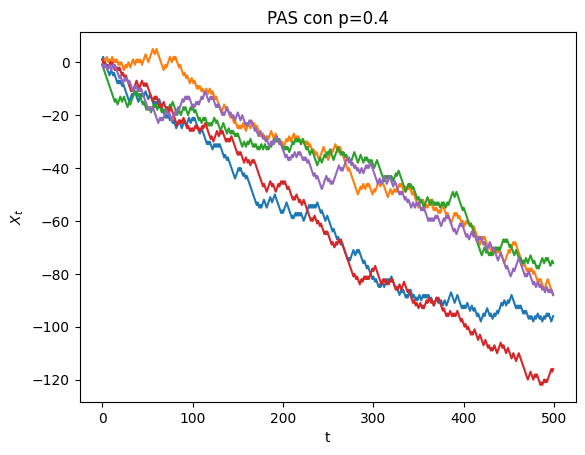

In [ ]:
# Dibujamos la gráfica
plt.plot(x_t)

# Damos título a la gráfica y a los ejes
plt.title("PAS con p=0.4")
plt.xlabel("t")
plt.ylabel("$X_t$")

##Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

In [ ]:
# En esta sección vamos a graficar 20 trayectorias
reps = 20

Podemos calcular la media teórica $E[X_n]$ de forma cerrada: $$E[X_n] = E[\sum_{i=1}^{n} Z_i] = \sum_{i=1}^{n}E[Z_i] = (2p-1)n$$

Por otra parte, la varianza teórica se calcula como sigue: $$Var(X_n) = \sum_{i=1}^{n}Var(Z_i) = 4p(1-p)n$$


Se define la función `media_desviación` para calcular la media teórica y la desviación típica del PAS. Recibe dos argumentos:

*   p es la probabilidad de tomar el valor 1 en cada paso. Es un valor entre 0 y 1.
*   n es el número de pasos. Es un número natural.

La función devuelve dos vectores de dimensión n.


In [ ]:
def media_desviacion (p,n):
    """
    Input:
      p: la probabilidad de tomar el valor 1 en cada paso
      n: el número de pasos
    Output:
      E_x_t: la media teórica
      sigma_x_t: la desviación típica teórica
    """
    # Obtenemos n puntos equiespaciados
    x = np.arange(0, n)

    # Calculamos la media teórica
    E_x_t = (2 * p - 1) * x

    # Calculamos la varianza teórica
    Var_x_t = 4 * p * (1 - p) * x

    # Calculamos la desviación típica como la raíz cuadrada de la varianza
    sigma_x_t = np.sqrt(Var_x_t)

    # Devolvemos la media y la desviación
    return E_x_t, sigma_x_t

**Funciones empleadas:**

Se ha usado la función `numpy.arange` para obtener n puntos equiespaciados.

La función `numpy.sqrt` permite calcular la raíz cuadrada de los elementos de un vector.

Se define a continuación la función `dibujar_media_desv`, que permite graficar el PAS y sus distintas trayectorias, así como la media teórica, $\pm \sigma$ y $\pm 2\sigma$. Recibe:

*   x es una matriz con forma (reps, n) que representa reps trayectorias de un PAS de n pasos.
*   E es la media teórica del PAS a representar. Es un vector de dimensión n.
*   sigma es la desviación típica teórica del PAS que se va a representar. Es un vector de dimensión n.

Devuelve una gráfica

In [ ]:
def dibujar_media_desviacion(x, E, sigma):
  """
    Input:
      x: matriz con forma (reps, n) que representa reps trayectorias de un PAS de n pasos.
      E: la media teórica del PAS a representar.
      sigma: la desviación típica teórica del PAS que se va a representar.
    Outout:
      ax: una gráfica
  """
  ax = plt.subplot()

  # Dibujamos la gráfica
  ax.plot(x, lw = 0.8)

  # Incluimos una rejilla en el fondo
  ax.grid(True, linestyle='--', linewidth=0.5)

  # Dibujamos la media teórica, la etiqueta permite añadirla a la leyenda
  ax.plot(E, "r--", label="Media teórica")

  # Obtenemos 500 puntos equiespaciados
  t = np.arange(500)

  # Dibujamos las desviaciones típicas y añadimos sus etiquetas correspondientes
  ax.fill_between(t, E+2*sigma, E-2*sigma, alpha = 0.2, color="grey", label=r"$\pm 2\sigma$")
  ax.fill_between(t, E+sigma, E-sigma, alpha = 0.3, color="grey", label=r"$\pm \sigma$")

  # Incluimos la leyenda
  ax.legend()

  # Damos título a la gráfica y a los ejes
  ax.set_title("PAS con media y desviación teóricas")
  ax.set_xlabel("t")
  ax.set_ylabel("$X_t$")

  return ax

**Funciones empleadas:**

La función `subplot` permite crear el lienzo y los ejes donde se va a dibujar las gráficas.

La función `fill_between` permite colorear el área entre dos funciones.

La función `legend` permite mostrar una legenda.

###PAS con p = 0.5

In [ ]:
p = 0.5

In [ ]:
# Llamamos a la función simular_PAS con probabilidad de 0.5, 500 pasos y 20 repeticiones
x_t = simular_PAS(p, n, reps)

# Se traspone la matriz
x_t = np.transpose(x_t)

In [ ]:
# Se calcula la media teórica y la desviación
E_x_t, sigma_x_t = media_desviacion(0.5, n)

# Si se quieren ver los resultados, descomentar la línea inferior
# E_x_t, sigma_x_t

<Axes: title={'center': 'PAS con media y desviación teóricas'}, xlabel='t', ylabel='$X_t$'>

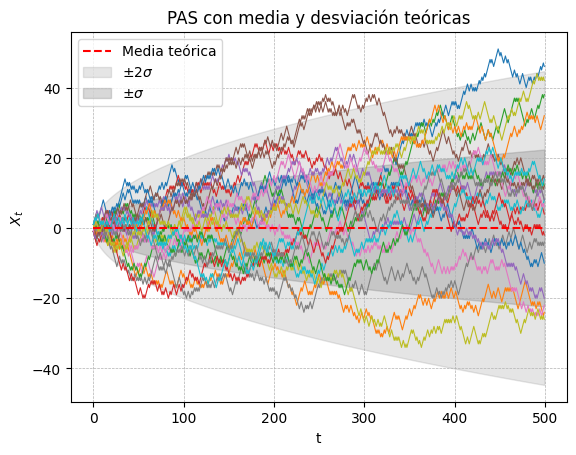

In [ ]:
dibujar_media_desviacion(x_t, E_x_t, sigma_x_t)

###PAS con p = 0.75

In [ ]:
p = 0.75

In [ ]:
# Llamada a la función simular_PAS con probabilidad de 0.75, 500 pasos y 20 repeticiones
x_t = simular_PAS(p, n, reps)
x_t = np.transpose(x_t)

In [ ]:
# Se calcula la media teórica y la varianza

E_x_t, sigma_x_t = media_desviacion(0.75, n)

<Axes: title={'center': 'PAS con media y desviación teóricas'}, xlabel='t', ylabel='$X_t$'>

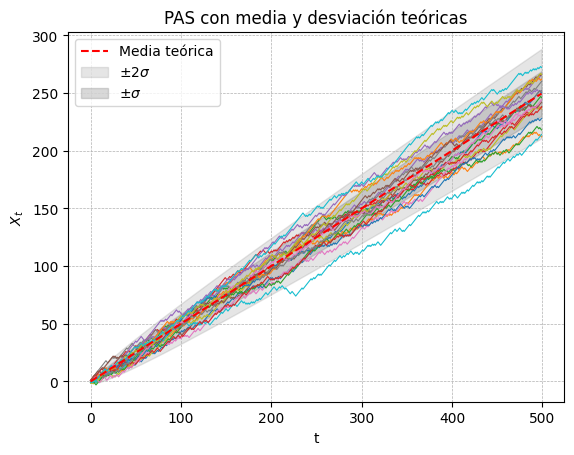

In [ ]:
dibujar_media_desviacion(x_t, E_x_t, sigma_x_t)

###PAS con p = 0.95

In [ ]:
p = 0.95

In [ ]:
# Llamada a la función simular_PAS con probabilidad de 0.95, 500 pasos y 20 repeticiones
x_t = simular_PAS(p, n, reps)
x_t = np.transpose(x_t)

In [ ]:
# Se calcula la media teórica y la varianza

E_x_t, sigma_x_t = media_desviacion(0.95, n)

<Axes: title={'center': 'PAS con media y desviación teóricas'}, xlabel='t', ylabel='$X_t$'>

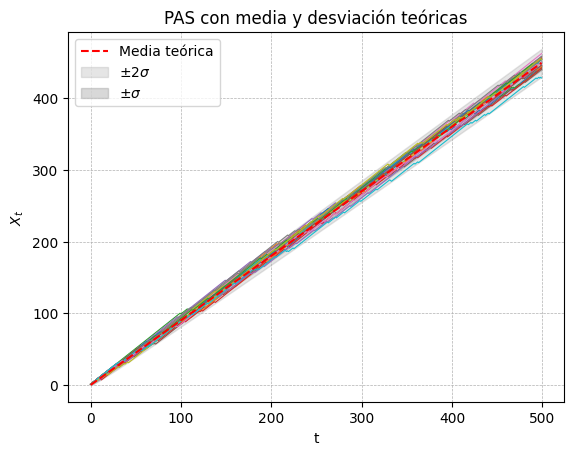

In [ ]:
dibujar_media_desviacion(x_t, E_x_t, sigma_x_t)

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

En esta sección se compara la media empírica del Paseo Aleatorio Simple, obtenida a partir de un número creciente de trayectorias simuladas, con la media teórica del proceso.

Para un número pequeño de trayectorias, la media empírica presenta una alta variabilidad y puede alejarse significativamente de la media teórica. Sin embargo, a medida que aumenta el número de trayectorias consideradas, esta media se estabiliza progresivamente y se aproxima al valor esperado.

Este comportamiento es una manifestación de la Ley de los Grandes Números, que establece que la media de variables aleatorias independientes e idénticamente distribuidas converge, en probabilidad, a su valor esperado cuando el tamaño de la muestra tiende a infinito.

Para esto, se va a usar la función `numpy.mean`, que permite calcular la media de los elementos de un array.

In [ ]:
p = 0.5
reps = 1000

Text(0, 0.5, 'X_t')

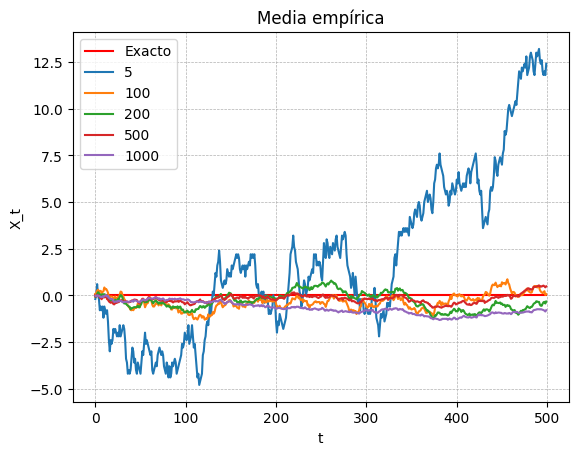

In [ ]:
# Simulamos 1000 trayectorias
x_1000 = simular_PAS(p, n, reps)

# Calculamos la media exacta, recibimos también la desviación, ya que la función
# devuelve ambos cálculos.
E_x_t, sigma_x_t = media_desviacion(p, n)

# Dibujamos solo la media
plt.plot(E_x_t, "r", label="Exacto")

lista_reps = [5, 100, 200, 500, 1000]

# Iteramos sobre la lista para calcular la media de las trayectorias indicadas
# en cada posición de la lista
for reps in lista_reps:
  # Calculamos la media de las reps primeras trayectorias y la dibujamos
  media = np.mean(x_1000[:reps], axis=0)
  plt.plot(media, label=f"{reps}")

# Formateamos la gráfica
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5) # Permite mostrar una cuadricula
plt.title("Media empírica")
plt.xlabel("t")
plt.ylabel("X_t")